TASK 7: Virtual Trading on StockGro + TASK 8: Predicted vs Actual

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from config import tickers as TICKERS, virtual_capital as TOTAL_CAPITAL
TICKER_LIST = list(TICKERS.values())
SECTOR_MAP = {v: k for k, v in TICKERS.items()}

TASK 7: Record your actual trades here

In [2]:
trades = {
    'Stock'        : TICKER_LIST,
    'Shares Bought': [443, 255, 102, 25, 57],
    'Buy Price'    : [743.25, 1096.39, 1826.92, 3090.04, 2235.44],
    'Allocation'   : [220745, 92097, 297789, 64891, 165423],
}


actual_day1 = {
    'HDFCBANK.NS': 759.28, 'INFY.NS': 1083.81, 'SUNPHARMA.NS': 1845.28, 'M&M.NS': 3087.91, 'HINDUNILVR.NS': 2227.14
}
actual_day2 = {
    'HDFCBANK.NS': 762.63, 'INFY.NS': 1106.86, 'SUNPHARMA.NS': 1849.30, 'M&M.NS': 3087.91, 'HINDUNILVR.NS': 2257.53
}


Load ensemble forecasts from notebook 04

In [3]:
ensemble_fc = pd.read_csv('../outputs/forecasts/ensemble_forecasts.csv')
portfolio  = pd.read_csv('../outputs/forecasts/portfolio_allocation.csv')
comparison = []
for _, row in ensemble_fc.iterrows():
    ticker = row['Stock']
    pred_d1 = row['Forecast Day 1']
    pred_d2 = row['Forecast Day 2']
    act_d1  = actual_day1.get(ticker, 0)
    act_d2  = actual_day2.get(ticker, 0)
    if act_d1 > 0 and act_d2 > 0:
        mape_d1 = abs(act_d1 - pred_d1) / act_d1 * 100
        mape_d2 = abs(act_d2 - pred_d2) / act_d2 * 100
        dir_correct = (pred_d2 > pred_d1) == (act_d2 > act_d1)
        comparison.append({
            'Stock'           : ticker,
            'Sector'          : SECTOR_MAP[ticker],
            'Allocation (₹)'  : portfolio[portfolio['Stock'] == ticker]['Allocation (₹)'].values[0],
            'Pred Day 1'      : round(pred_d1, 2),
            'Actual Day 1'    : round(act_d1, 2),
            'MAPE Day 1 (%)'  : round(mape_d1, 2),
            'Pred Day 2'      : round(pred_d2, 2),
            'Actual Day 2'    : round(act_d2, 2),
            'MAPE Day 2 (%)'  : round(mape_d2, 2),
            'Dir Correct'      : '✓' if dir_correct else '✗'
        })
comp_df = pd.DataFrame(comparison)

In [4]:
print("=" * 80)
print("TASK 8 — Predicted vs Actual (StockGro 2-Day Window)")
print("=" * 80)
print(comp_df.to_string(index=False))
# Portfolio performance
if len(comparison) > 0:
    port_return = 0
    for row in comparison:
        alloc = row['Allocation (₹)']
        if row['Actual Day 2'] > 0 and row['Pred Day 1'] > 0:
            ret = (row['Actual Day 2'] - row['Actual Day 1']) / row['Actual Day 1']
            port_return += alloc * ret / TOTAL_CAPITAL
    print(f"\n{'='*80}")
    print(f"Portfolio Return over 2-day window: {port_return*100:.2f}%")
    print(f"Total Capital: ₹{TOTAL_CAPITAL:,.0f}")
    print(f"Absolute Return: ₹{port_return * TOTAL_CAPITAL:,.2f}")
    print("=" * 80)

TASK 8 — Predicted vs Actual (StockGro 2-Day Window)
        Stock  Sector  Allocation (₹)  Pred Day 1  Actual Day 1  MAPE Day 1 (%)  Pred Day 2  Actual Day 2  MAPE Day 2 (%) Dir Correct
  HDFCBANK.NS Banking       329420.64      998.73        759.28           31.54      999.71        762.63           31.09           ✓
      INFY.NS      IT       279947.24     1634.85       1083.81           50.84     1635.90       1106.86           47.80           ✓
 SUNPHARMA.NS  Pharma       184954.08     1718.77       1845.28            6.86     1716.53       1849.30            7.18           ✗
       M&M.NS    Auto        77646.84     3482.35       3087.91           12.77     3484.29       3087.91           12.84           ✗
HINDUNILVR.NS    FMCG       128031.21     2295.11       2227.14            3.05     2297.10       2257.53            1.75           ✓

Portfolio Return over 2-day window: 0.96%
Total Capital: ₹1,000,000
Absolute Return: ₹9,557.18


Plot: Predicted vs Actual

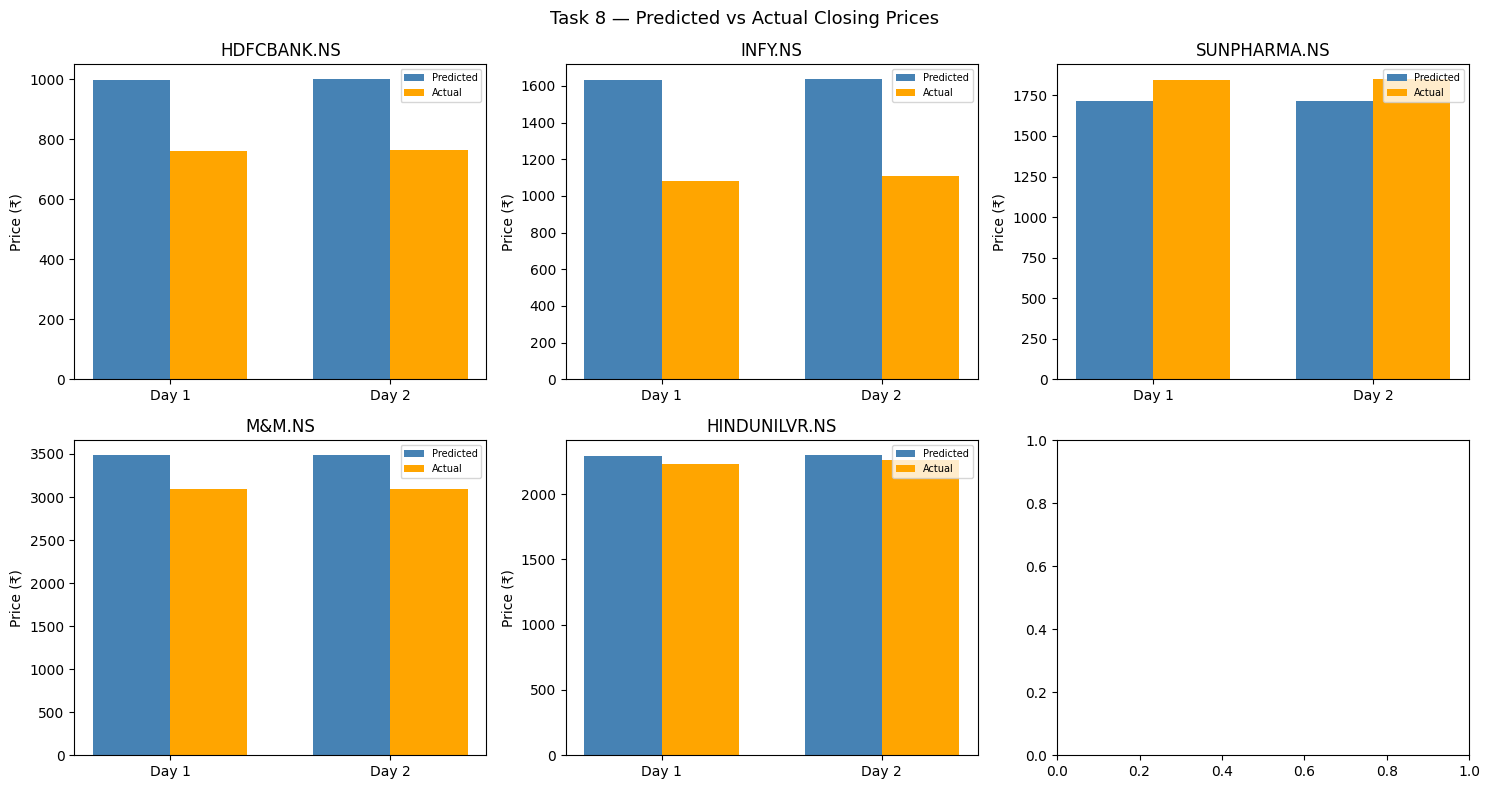

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, ticker in enumerate(TICKER_LIST):
    if i >= 5:
        break
    row = comp_df[comp_df['Stock'] == ticker]
    if len(row) == 0:
        continue
    days = ['Day 1', 'Day 2']
    pred_vals = [row['Pred Day 1'].values[0], row['Pred Day 2'].values[0]]
    act_vals  = [row['Actual Day 1'].values[0], row['Actual Day 2'].values[0]]
    x = np.arange(len(days))
    width = 0.35
    axes[i].bar(x - width/2, pred_vals, width, label='Predicted', color='steelblue')
    axes[i].bar(x + width/2, act_vals, width, label='Actual', color='orange')
    axes[i].set_title(f'{ticker}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(days)
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Price (₹)')
plt.suptitle('Task 8 — Predicted vs Actual Closing Prices', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/plots/11_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()